# experiment analyzer

here i need to plot for gcns: CCC / RMSE relative to persistence, per horizon. I believe the distance gros.

I need to plot the same for GCNLSTM and GATv2 to see hwether that holds.

In [25]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import wilcoxon
import scipy.stats

from src.utils.helpers import get_wissdaten_env
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ClimaScaleModel
from src.models.deep.deepmodel import DeepModel
from src.evaluation import Evaluator


# ═══════════════════════════════════════════════════════════════════════════
# 1. EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_experiment(
    experiment_subdir:  str,
    base_config:        dict,
    horizon_leadtimes:  list,
) -> pd.DataFrame:
    """
    Load saved models, forecast, evaluate.
    Returns flat metrics dataframe with columns:
    horizon, seed, model, node, ccc, mae, ...
    """
    all_metrics = []

    for hl in horizon_leadtimes:
        print(f"\n── hl={hl} ──────────────────────────────────────")

        cfg       = EpiConfig(horizon_leadtime=hl, **base_config)
        data_orch = EpiDataOrchestrator(cfg).build()

        baseline_dlm = BaseLineDataLoaderManager(data_orch)
        persistence  = PersistenceModel(baseline_dlm,  f'persistence_hl{hl}')
        climatology  = ClimateologyModel(baseline_dlm, f'climateology_hl{hl}')
        climascale   = ClimaScaleModel(baseline_dlm,   f'climascale_hl{hl}')
        persistence.forecast('test')
        climatology.forecast('test')
        climascale.forecast('test')
        baselines = [persistence, climatology, climascale]

        absolute_path = os.path.join(get_wissdaten_env(),'project_utilities/infectious_disease_gnn/models', experiment_subdir)

        hl_files = [
            f for f in os.listdir(absolute_path)
            if f.endswith('.pt') and f'_hl{hl}_' in f
        ]

        if not hl_files:
            print(f"  no files for hl={hl}, skipping")
            continue

        seed_pattern = re.compile(r'_s(\d+)\.pt$')
        seeds_found  = sorted(set(
            int(seed_pattern.search(f).group(1))
            for f in hl_files if seed_pattern.search(f)
        ))
        print(f"  seeds: {seeds_found}")

        for seed in seeds_found:
            seed_files  = [f for f in hl_files if f'_s{seed}.pt' in f]
            deep_models = []

            for modelfile in seed_files:
                name = modelfile.replace('.pt', '')
                try:
                    model = DeepModel.load(name, experiment_subdir)
                    model.forecast('test')
                    deep_models.append(model)
                except Exception as e:
                    print(f"  failed: {name} — {e}")
                    continue

            if not deep_models:
                continue

            all_models = baselines + deep_models
            evaluator  = Evaluator(all_models)
            evaluator.add_evaluation(horizon=0, dataset='test')

            metrics            = evaluator.data_compilation.get_data(0, 'test')['metrics'].copy()
            metrics['horizon'] = hl
            metrics['seed']    = seed
            metrics['model']   = (
                metrics['model'].astype(str)
                .str.replace(f'_hl{hl}_s{seed}', '', regex=False)
                .str.replace(f'_hl{hl}',         '', regex=False)
            )

            all_metrics.append(metrics)
            del evaluator, deep_models, all_models
            print(f"  seed={seed} done")

        del data_orch

    return pd.concat(all_metrics, ignore_index=True)


# ═══════════════════════════════════════════════════════════════════════════
# 2. SUMMARISE
# ═══════════════════════════════════════════════════════════════════════════

def summarise_from_metrics_df(
    metrics_df: pd.DataFrame,
    metric:     str = 'ccc',
):
    """
    Aggregate metric across seeds per model per horizon.
    Std is computed across seed means, not raw node observations.

    Returns
    -------
    per_seed : mean per (horizon, model, seed)
    summary  : mean ± std across seeds per (horizon, model)
    """
    pers = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby('horizon')[metric]
        .mean()
        .rename('pers_mean')
    )

    df                     = metrics_df.merge(pers, on='horizon')
    df[f'{metric}_delta']  = df[metric] - df['pers_mean']

    # step 1: average across nodes within each seed
    per_seed = (
        df.groupby(['horizon', 'model', 'seed'])
        [[metric, f'{metric}_delta']]
        .mean()
        .reset_index()
    )

    # step 2: aggregate across seeds
    summary = (
        per_seed.groupby(['horizon', 'model'])
        .agg(
            mean       = (metric,            'mean'),
            std        = (metric,            'std'),
            mean_delta = (f'{metric}_delta', 'mean'),
            std_delta  = (f'{metric}_delta', 'std'),
        )
        .round(4)
        .reset_index()
    )

    return per_seed, summary


def print_summary_table(summary: pd.DataFrame, metric: str = 'ccc'):
    pivot = summary.pivot_table(
        index='model', columns='horizon', values='mean_delta'
    ).round(4)
    print(f"\n── Mean {metric} delta over persistence ──────────────────────")
    print(pivot.to_string())

    pivot_std = summary.pivot_table(
        index='model', columns='horizon', values='std_delta'
    ).round(4)
    print(f"\n── Std across seeds ──────────────────────────────────────────")
    print(pivot_std.to_string())


# ═══════════════════════════════════════════════════════════════════════════
# 3. GRAPH STRUCTURE EFFECT PLOT
# ═══════════════════════════════════════════════════════════════════════════

def plot_graph_structure_effect(
    per_seed:           pd.DataFrame,
    models_to_compare:  dict,
    metric:             str = 'ccc',
    title:              str = 'Graph structure effect across horizons',
):
    """
    Plots within-architecture gap between graph types across horizons.

    models_to_compare: dict of label -> (model_a, model_b)
        plotted value = model_a metric - model_b metric
    """
    palette = {
        'geo − identity'    : '#2196F3',
        'geo − random'      : '#4CAF50',
        'commuter − random' : '#FF9800',
        'geo − lstm'        : '#9C27B0',
    }

    horizons = sorted(per_seed['horizon'].unique())
    seeds    = sorted(per_seed['seed'].unique())

    gap_records = []
    for label, (model_a, model_b) in models_to_compare.items():
        for hl in horizons:
            for seed in seeds:
                row_a = per_seed[
                    (per_seed['horizon'] == hl) &
                    (per_seed['seed']    == seed) &
                    (per_seed['model']   == model_a)
                ]
                row_b = per_seed[
                    (per_seed['horizon'] == hl) &
                    (per_seed['seed']    == seed) &
                    (per_seed['model']   == model_b)
                ]
                if row_a.empty or row_b.empty:
                    continue

                gap_records.append({
                    'horizon' : hl,
                    'seed'    : seed,
                    'label'   : label,
                    'gap'     : row_a[metric].values[0] - row_b[metric].values[0],
                })

    gap_df = pd.DataFrame(gap_records)
    gap_summary = (
        gap_df.groupby(['horizon', 'label'])['gap']
        .agg(mean='mean', std='std')
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for label in models_to_compare:
        sub   = gap_summary[gap_summary['label'] == label].sort_values('horizon')
        color = palette.get(label, 'black')

        ax.plot(sub['horizon'], sub['mean'],
                label=label, color=color, marker='o', linewidth=2)
        ax.fill_between(
            sub['horizon'],
            sub['mean'] - sub['std'],
            sub['mean'] + sub['std'],
            color=color, alpha=0.12
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
    ax.set_ylabel(f'Δ {metric.upper()} (positive = first model better)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n── Gap means ────────────────────────────────────────────────")
    print(gap_summary.pivot_table(
        index='label', columns='horizon', values='mean'
    ).round(4).to_string())

    return fig, gap_df, gap_summary


# ═══════════════════════════════════════════════════════════════════════════
# 4. WILCOXON
# ═══════════════════════════════════════════════════════════════════════════

def node_level_significance(
    metrics_df:         pd.DataFrame,
    completed_horizons: list,
    model_a:            str = 'gcn_geo',
    model_b:            str = 'gcn_identity',
    metric:             str = 'ccc',
):
    """Paired Wilcoxon test on node-level metric across seeds."""
    records = []

    for hl in completed_horizons:
        hl_df = metrics_df[metrics_df['horizon'] == hl].copy()
        hl_df['node'] = hl_df['node'].astype(int)

        seeds = sorted(hl_df['seed'].unique())
        a_values, b_values = [], []

        for seed in seeds:
            seed_df = hl_df[hl_df['seed'] == seed]

            a = seed_df[seed_df['model'] == model_a].set_index('node')[metric]
            b = seed_df[seed_df['model'] == model_b].set_index('node')[metric]

            common = a.index.intersection(b.index)
            if len(common) == 0:
                continue

            a_values.append(a.loc[common].values)
            b_values.append(b.loc[common].values)

        if not a_values:
            continue

        a_all = np.concatenate(a_values)
        b_all = np.concatenate(b_values)
        diffs = a_all - b_all
        diffs = diffs[~np.isnan(diffs)]

        if len(diffs) == 0 or np.all(diffs == 0):
            continue

        stat, p     = wilcoxon(diffs, alternative='greater')
        median_diff = np.median(diffs)

        records.append({
            'horizon':     hl,
            'model_a':     model_a,
            'model_b':     model_b,
            'n':           len(diffs),
            'W':           stat,
            'p':           p,
            'median_diff': median_diff,
            'significant': p < 0.05,
        })

        sig = '*' if p < 0.05 else ''
        print(f"hl={hl:2d} | {model_a} vs {model_b} | "
              f"n={len(diffs)}  W={stat:.0f}  p={p:.4f}  "
              f"median_diff={median_diff:+.4f}  {sig}")

    return pd.DataFrame(records)


# ═══════════════════════════════════════════════════════════════════════════
# 5. DEGRADATION RATE
# ═══════════════════════════════════════════════════════════════════════════

def degradation_rate(summary: pd.DataFrame, metric: str = 'ccc'):
    """Linear regression of mean_delta (or mean) vs horizon per model."""
    
    # use mean_delta if available, otherwise mean
    value_col = 'mean_delta' if 'mean_delta' in summary.columns else 'mean'
    
    records = []
    for model in summary['model'].unique():
        sub = summary[summary['model'] == model].sort_values('horizon')
        if len(sub) < 3:
            continue

        slope, intercept, r, p, se = scipy.stats.linregress(
            sub['horizon'], sub[value_col]
        )
        records.append({
            'model'    : model,
            'slope'    : round(slope, 4),
            'intercept': round(intercept, 4),
            'r2'       : round(r**2, 3),
            'p'        : round(p, 4),
        })
        print(f"{model:25s}  slope={slope:+.4f}  r²={r**2:.3f}  p={p:.4f}")

    return pd.DataFrame(records).sort_values('slope', ascending=False)
# ═══════════════════════════════════════════════════════════════════════════
# 6. RELATIVE RMSE
# ═══════════════════════════════════════════════════════════════════════════

def relative_rmse_table(
    metrics_df: pd.DataFrame,
    models:     list = None,
):
    """Mean and median % RMSE change vs persistence per model per horizon."""
    from sklearn.metrics import mean_squared_error

    if models is None:
        models = [m for m in metrics_df['model'].unique() if m != 'persistence']

    # persistence rmse per horizon per seed per node — need original preds
    # this version works from the metrics_df if rmse is already computed
    if 'rmse' not in metrics_df.columns:
        print("rmse column not found in metrics_df — skipping")
        return None

    pers_rmse = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby(['horizon', 'seed', 'node'])['rmse']
        .mean()
        .reset_index()
        .rename(columns={'rmse': 'pers_rmse'})
    )

    df = metrics_df[metrics_df['model'].isin(models)].merge(
        pers_rmse, on=['horizon', 'seed', 'node']
    )
    df['rmse_rel'] = (df['rmse'] - df['pers_rmse']) / df['pers_rmse'] * 100

    # winsorise
    lo = df['rmse_rel'].quantile(0.01)
    hi = df['rmse_rel'].quantile(0.99)
    df['rmse_rel_w'] = df['rmse_rel'].clip(lo, hi)

    for stat, label in [('rmse_rel', 'Median'), ('rmse_rel_w', 'Winsorised mean')]:
        agg  = 'median' if stat == 'rmse_rel' else 'mean'
        pivot = (df.groupby(['horizon', 'model'])[stat]
                 .agg(agg)
                 .unstack('model')
                 .loc[:, [m for m in models if m in df['model'].unique()]]
                 .round(1))
        print(f"\n── {label} % RMSE vs persistence (negative = better) ──")
        print(pivot.to_string())

    return df


── hl=1 ──────────────────────────────────────
  seeds: [8, 21, 42, 123, 456]


computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:09<00:00, 698.10it/s]


  seed=8 done


computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:09<00:00, 695.04it/s]


  seed=21 done


...

  seed=42 done


computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:21<00:00, 291.93it/s]


  seed=123 done


computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:20<00:00, 310.84it/s]


  seed=456 done

── Mean ccc delta over persistence ──────────────────────
horizon            1       2       3       4       5       6       7
model                                                               
climascale   -0.0168  0.0405  0.1256  0.2139  0.2934  0.3580  0.4235
climateology -0.0834  0.0513  0.1959  0.3254  0.4611  0.5947  0.6985
gcn_commuter  0.0196  0.0897  0.2114  0.3330  0.4463  0.5558  0.6447
gcn_geo       0.0232  0.0878  0.2140  0.3429  0.4601  0.5707  0.6610
gcn_identity  0.0021  0.0734  0.1918  0.3073  0.4143  0.5147  0.5936
gcn_random    0.0056  0.0680  0.2027  0.3239  0.4350  0.5516  0.6414
lstm          0.0224  0.0965  0.2176  0.3272  0.4411  0.5370  0.5938
persistence   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

── Std across seeds ──────────────────────────────────────────
horizon            1       2       3       4       5       6       7
model                                                               
climascale    0.0000  0.0000  0.0

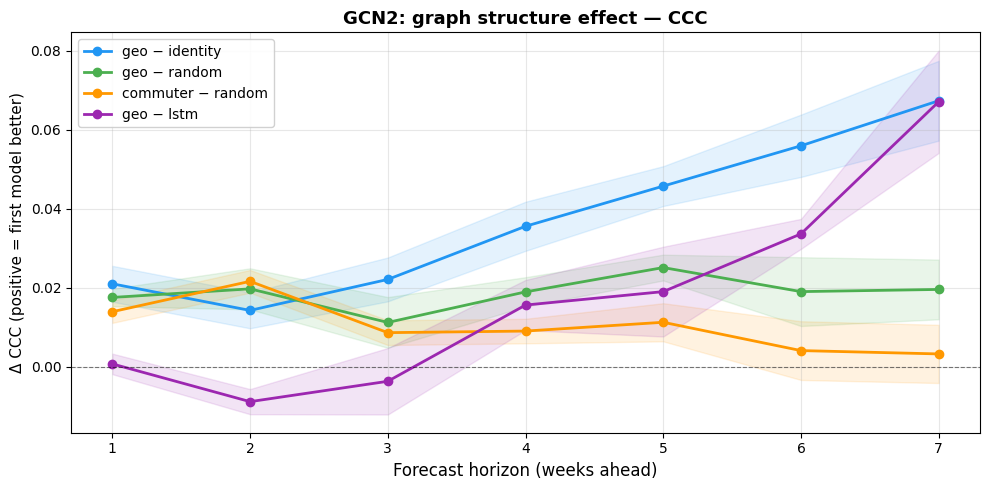


── Gap means ────────────────────────────────────────────────
horizon                 1       2       3       4       5       6       7
label                                                                    
commuter − random  0.0140  0.0217  0.0087  0.0091  0.0113  0.0041  0.0033
geo − identity     0.0211  0.0143  0.0222  0.0356  0.0458  0.0560  0.0674
geo − lstm         0.0008 -0.0088 -0.0036  0.0157  0.0191  0.0337  0.0671
geo − random       0.0176  0.0198  0.0113  0.0190  0.0252  0.0191  0.0196


── GRAPH STRUCTURE EFFECT: RMSE % ───────────────────────────────


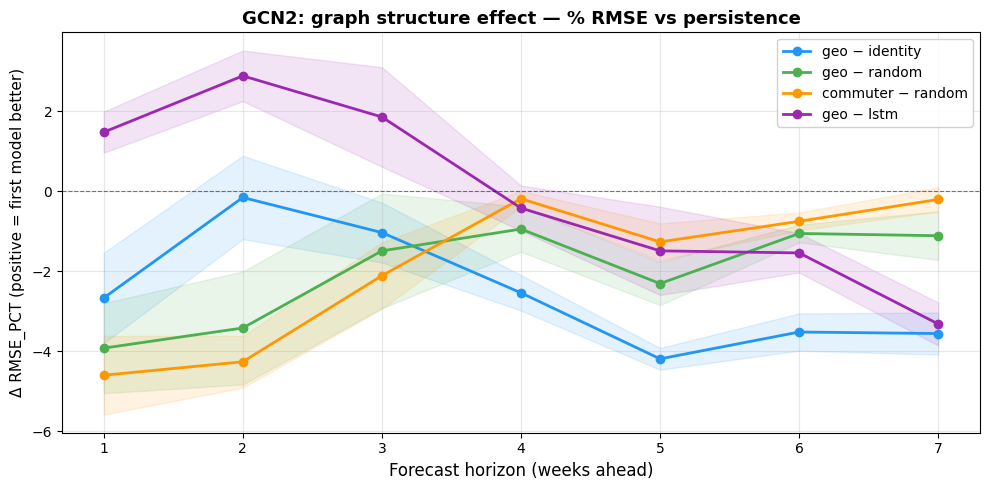


── Gap means ────────────────────────────────────────────────
horizon                 1       2       3       4       5       6       7
label                                                                    
commuter − random -4.6009 -4.2641 -2.1103 -0.1850 -1.2653 -0.7501 -0.2030
geo − identity    -2.6677 -0.1539 -1.0318 -2.5394 -4.1912 -3.5196 -3.5581
geo − lstm         1.4797  2.8888  1.8602 -0.4194 -1.4894 -1.5411 -3.3194
geo − random      -3.9226 -3.4186 -1.4895 -0.9439 -2.3083 -1.0541 -1.1109

── Wilcoxon (CCC): geo vs identity ──────────────────────────────
hl= 1 | gcn_geo vs gcn_identity | n=1995  W=1518512  p=0.0000  median_diff=+0.0174  *
hl= 2 | gcn_geo vs gcn_identity | n=1995  W=1276380  p=0.0000  median_diff=+0.0122  *
hl= 3 | gcn_geo vs gcn_identity | n=1995  W=1389980  p=0.0000  median_diff=+0.0197  *
hl= 4 | gcn_geo vs gcn_identity | n=1995  W=1569620  p=0.0000  median_diff=+0.0350  *
hl= 5 | gcn_geo vs gcn_identity | n=1995  W=1619423  p=0.0000  median_diff=+0.0469

KeyError: 'mean_delta'

In [ ]:
BASE_CONFIG = dict(
    disease              = 'influenza',
    country              = 'germany',
    level                = 'nuts3',
    min_date             = '2012-06-01',
    max_date             = '2020-06-01',
    feature_popsize      = False,
    feature_popdens      = True,
    feature_gisd         = False,
    feature_popage       = False,
    feature_kreise_classes = False,
    feature_borders      = False,
    sequence_length      = 4,
    normalization_method = 'zscore',
    log_transform        = ['incidence'],
)

experiment_subdir = 'experiment_1'

# ── evaluate ──────────────────────────────────────────────────────────────
# metrics_df = evaluate_experiment(
#     experiment_subdir = experiment_subdir,
#     base_config       = BASE_CONFIG,
#     horizon_leadtimes = list(range(1, 8)),
# )




── Mean ccc delta over persistence ──────────────────────
horizon                  1       2       3       4       5       6       7
model                                                                     
climascale         -0.0168  0.0405  0.1256  0.2139  0.2934  0.3580  0.4235
climateology       -0.0834  0.0513  0.1959  0.3254  0.4611  0.5947  0.6985
gatv2lstm_commuter  0.0327  0.1055  0.2325  0.3548  0.4597  0.5638  0.6393
gatv2lstm_geo       0.0348  0.1048  0.2292  0.3587  0.4716  0.5685  0.6523
gatv2lstm_identity  0.0289  0.1066  0.2267  0.3438  0.4488  0.5397  0.6133
gatv2lstm_random    0.0213  0.0961  0.2230  0.3483  0.4508  0.5418  0.5852
gcnlstm_commuter   -0.0539  0.0515  0.1772  0.2878  0.3993  0.5150  0.6016
gcnlstm_geo        -0.0053  0.0925  0.2178  0.3316  0.4449  0.5587  0.6444
gcnlstm_identity    0.0331  0.1196  0.2367  0.3405  0.4456  0.5509  0.6296
gcnlstm_random     -0.1533 -0.0332  0.0968  0.2051  0.3240  0.4468  0.5309
lstm                0.0224  0.0965  0.217

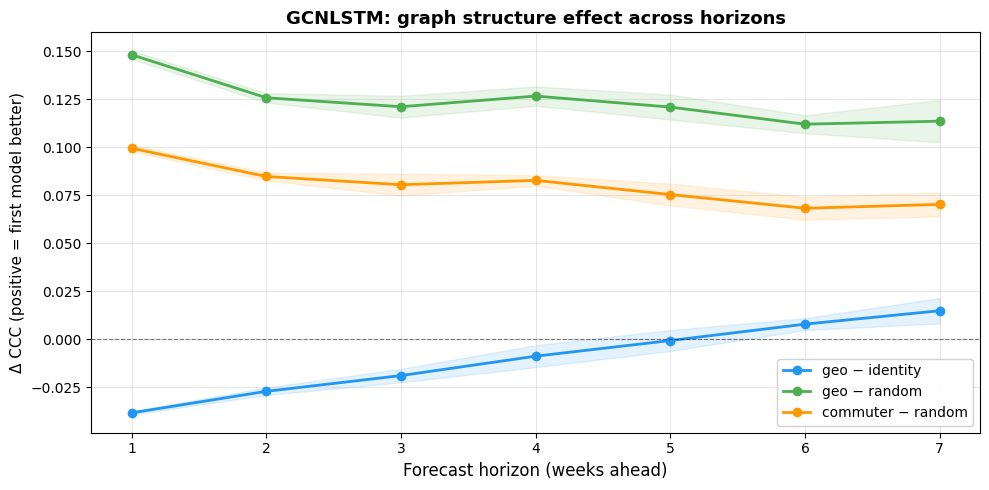


── Gap means ────────────────────────────────────────────────
horizon                 1       2       3       4       5       6       7
label                                                                    
commuter − random  0.0994  0.0847  0.0804  0.0827  0.0753  0.0682  0.0702
geo − identity    -0.0383 -0.0271 -0.0189 -0.0089 -0.0007  0.0078  0.0148
geo − random       0.1481  0.1257  0.1210  0.1266  0.1208  0.1119  0.1135

── GATv2LSTM: graph structure effect ────────────────────────────


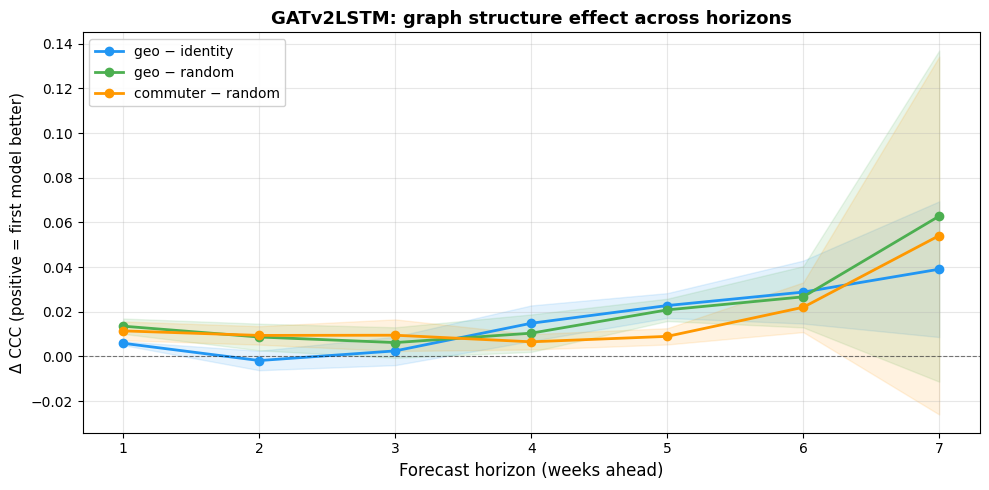


── Gap means ────────────────────────────────────────────────
horizon                 1       2       3       4       5       6       7
label                                                                    
commuter − random  0.0114  0.0094  0.0095  0.0066  0.0090  0.0220  0.0541
geo − identity     0.0059 -0.0018  0.0025  0.0149  0.0228  0.0288  0.0391
geo − random       0.0136  0.0087  0.0062  0.0104  0.0208  0.0267  0.0628

── Architecture comparison: geo − identity gap ───────────────────


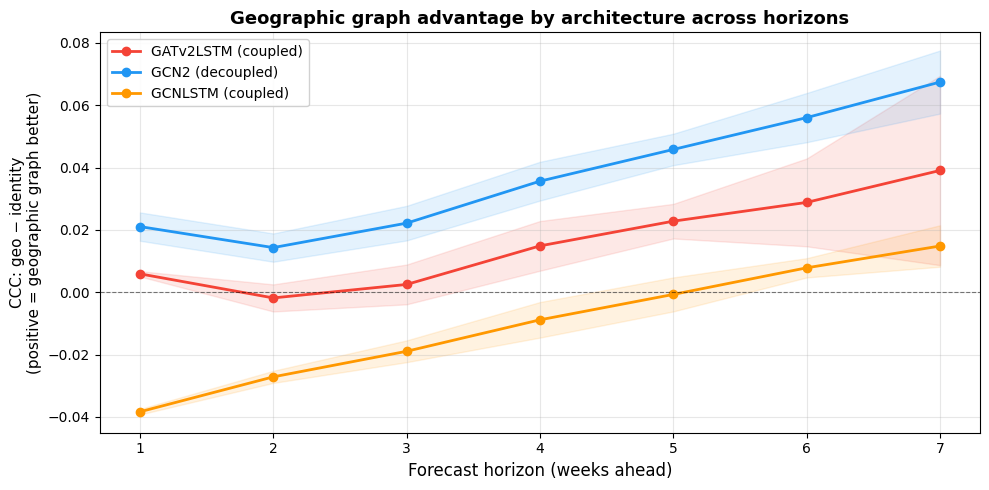

In [27]:
# ── add relative RMSE % ───────────────────────────────────────────────────
def add_relative_rmse(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Add rmse_pct column: % RMSE change vs persistence per node per seed per horizon."""
    pers = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby(['horizon', 'seed', 'node'])['rmse']
        .mean()
        .reset_index()
        .rename(columns={'rmse': 'pers_rmse'})
    )
    df = metrics_df.merge(pers, on=['horizon', 'seed', 'node'], how='left')
    df['rmse_pct'] = (df['rmse'] - df['pers_rmse']) / df['pers_rmse'] * 100
    return df

# ── exp2: coupled architectures ───────────────────────────────────────────
exp2_models = ['persistence', 'climateology', 'climascale', 'lstm',
               'gcnlstm_identity', 'gcnlstm_geo', 'gcnlstm_random', 'gcnlstm_commuter',
               'gatv2lstm_identity', 'gatv2lstm_geo', 'gatv2lstm_random', 'gatv2lstm_commuter']

# evaluate — only horizons where exp2 models exist
metrics_df_exp2 = metrics_df.copy()

metrics_exp2 = metrics_df_exp2[metrics_df_exp2['model'].isin(exp2_models)].copy()
metrics_exp2 = add_relative_rmse(metrics_exp2)

# summarise
per_seed_ccc_exp2, summary_ccc_exp2 = summarise_from_metrics_df(metrics_exp2, metric='ccc')
print_summary_table(summary_ccc_exp2, metric='ccc')

# ── key plot: within-architecture graph structure effect ──────────────────
print("\n── GCNLSTM: graph structure effect ──────────────────────────────")
fig_gcnlstm, _, _ = plot_graph_structure_effect(
    per_seed = per_seed_ccc_exp2[
        per_seed_ccc_exp2['model'].str.startswith('gcnlstm') |
        per_seed_ccc_exp2['model'].isin(['persistence'])
    ],
    models_to_compare = {
        'geo − identity'    : ('gcnlstm_geo',      'gcnlstm_identity'),
        'geo − random'      : ('gcnlstm_geo',      'gcnlstm_random'),
        'commuter − random' : ('gcnlstm_commuter', 'gcnlstm_random'),
    },
    metric = 'ccc',
    title  = 'GCNLSTM: graph structure effect across horizons',
)

print("\n── GATv2LSTM: graph structure effect ────────────────────────────")
fig_gatv2, _, _ = plot_graph_structure_effect(
    per_seed = per_seed_ccc_exp2[
        per_seed_ccc_exp2['model'].str.startswith('gatv2lstm') |
        per_seed_ccc_exp2['model'].isin(['persistence'])
    ],
    models_to_compare = {
        'geo − identity'    : ('gatv2lstm_geo',      'gatv2lstm_identity'),
        'geo − random'      : ('gatv2lstm_geo',      'gatv2lstm_random'),
        'commuter − random' : ('gatv2lstm_commuter', 'gatv2lstm_random'),
    },
    metric = 'ccc',
    title  = 'GATv2LSTM: graph structure effect across horizons',
)

# ── combined comparison: GCN2 vs GCNLSTM vs GATv2LSTM geo-identity gap ───
print("\n── Architecture comparison: geo − identity gap ───────────────────")

# extract geo-identity gap per architecture
def extract_geo_identity_gap(per_seed, geo_model, identity_model):
    horizons = sorted(per_seed['horizon'].unique())
    seeds    = sorted(per_seed['seed'].unique())
    records  = []
    for hl in horizons:
        for seed in seeds:
            a = per_seed[(per_seed['horizon']==hl) & (per_seed['seed']==seed) & (per_seed['model']==geo_model)]
            b = per_seed[(per_seed['horizon']==hl) & (per_seed['seed']==seed) & (per_seed['model']==identity_model)]
            if a.empty or b.empty:
                continue
            records.append({'horizon': hl, 'seed': seed,
                            'gap': a['ccc'].values[0] - b['ccc'].values[0]})
    return pd.DataFrame(records)

gap_gcn2     = extract_geo_identity_gap(per_seed_ccc,      'gcn_geo',      'gcn_identity')
gap_gcnlstm  = extract_geo_identity_gap(per_seed_ccc_exp2, 'gcnlstm_geo',  'gcnlstm_identity')
gap_gatv2    = extract_geo_identity_gap(per_seed_ccc_exp2, 'gatv2lstm_geo','gatv2lstm_identity')

gap_gcn2['architecture']    = 'GCN2 (decoupled)'
gap_gcnlstm['architecture'] = 'GCNLSTM (coupled)'
gap_gatv2['architecture']   = 'GATv2LSTM (coupled)'

all_gaps = pd.concat([gap_gcn2, gap_gcnlstm, gap_gatv2], ignore_index=True)
gap_agg  = all_gaps.groupby(['horizon', 'architecture'])['gap'].agg(mean='mean', std='std').reset_index()

# plot
fig_arch, ax = plt.subplots(figsize=(10, 5))
palette = {
    'GCN2 (decoupled)'  : '#2196F3',
    'GCNLSTM (coupled)' : '#FF9800',
    'GATv2LSTM (coupled)': '#F44336',
}

for arch in gap_agg['architecture'].unique():
    sub   = gap_agg[gap_agg['architecture'] == arch].sort_values('horizon')
    color = palette.get(arch, 'black')
    ax.plot(sub['horizon'], sub['mean'], label=arch, color=color, marker='o', linewidth=2)
    ax.fill_between(sub['horizon'],
                    sub['mean'] - sub['std'],
                    sub['mean'] + sub['std'],
                    color=color, alpha=0.12)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
ax.set_ylabel('CCC: geo − identity\n(positive = geographic graph better)', fontsize=11)
ax.set_title('Geographic graph advantage by architecture across horizons',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
ccc_distributions['model'].unique()

array(['persistence', 'climateology', 'climascale', 'lstm',
       'gatv2lstm_geo', 'gcn_random', 'gatv2lstm_commuter',
       'gcnlstm_identity', 'gcn_geo', 'gcn_identity', 'gcnlstm_commuter',
       'gcnlstm_geo', 'gatv2lstm_random', 'gcn_commuter',
       'gatv2lstm_identity', 'gcnlstm_random'], dtype=object)

In [22]:
ccc_distributions = metrics_df.copy()
ccc_distributions = ccc_distributions[['node','model','horizon','seed','ccc']]

df = ccc_distributions.copy()

mapping = {
    # baselines
    "persistence"   : "baseline",
    "climateology"  : "baseline",
    "climascale"    : "baseline",

    "lstm"          : "lstm",

    # gcn
    'gcn_random'    : 'gcn',
    'gcn_geo'       : 'gcn',
    'gcn_identity'  : 'gcn',
    'gcn_commuter'  : 'gcn',

    # gatv2lstm
    'gatv2lstm_geo'     : 'gatv2',
    'gatv2lstm_commuter': 'gatv2',
    'gatv2lstm_random'  : 'gatv2',
    'gatv2lstm_identity': 'gatv2',

    # gcnlstm
    'gcnlstm_identity'  : 'gcnlstm',
    'gcnlstm_commuter'  : 'gcnlstm',
    'gcnlstm_geo'       : 'gcnlstm',
    'gcnlstm_random'    : 'gcnlstm'
}

df["modeltype"] = df["model"].map(mapping)


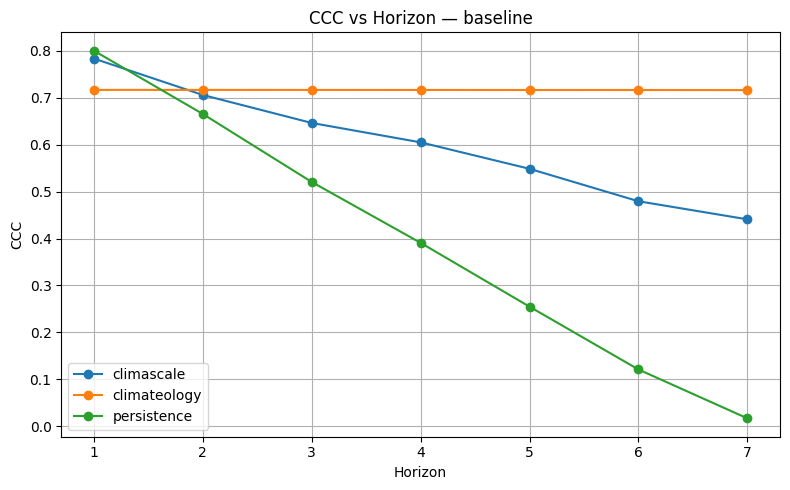

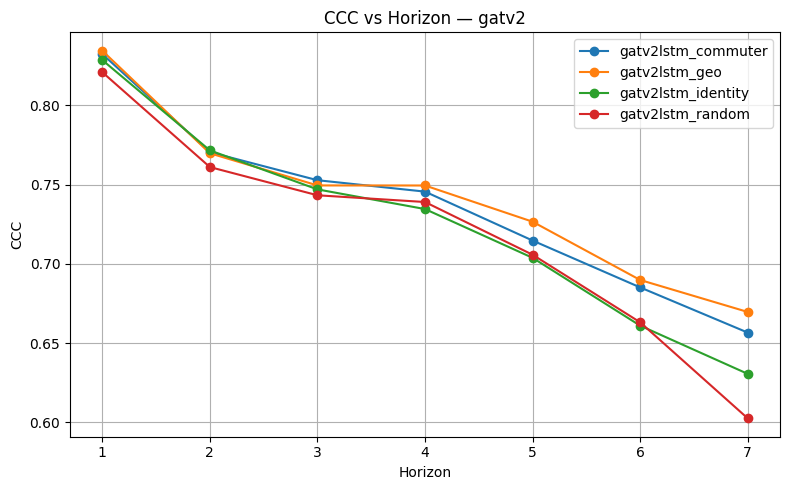

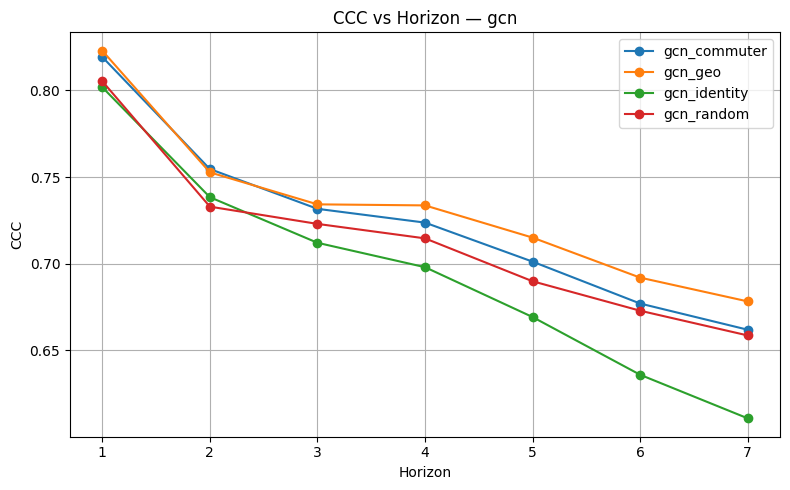

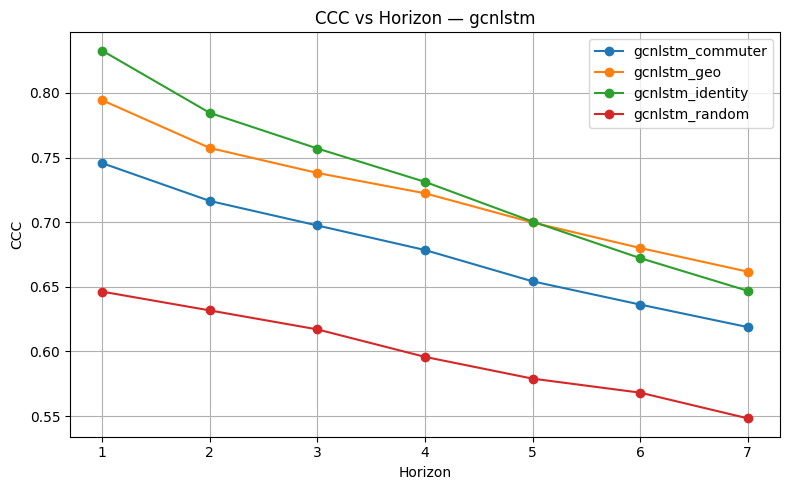

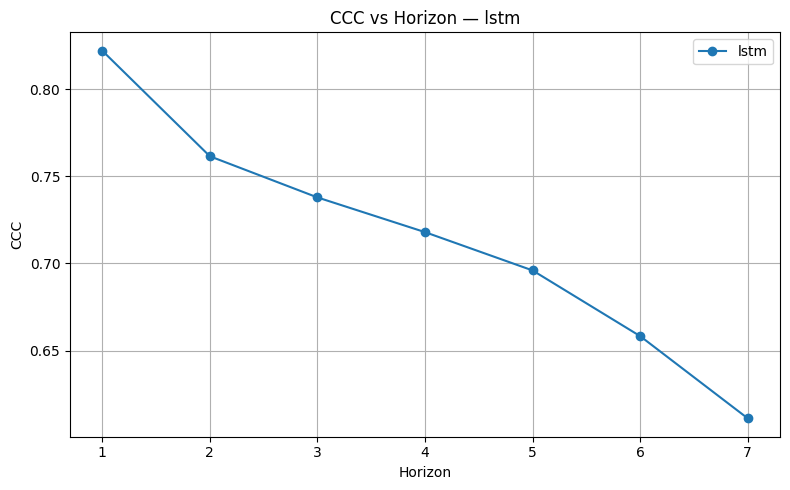

In [23]:
import matplotlib.pyplot as plt

# 1) aggregate over seeds (and nodes if needed)
agg = (
    df.groupby(["modeltype", "model", "horizon"])["ccc"]
    .mean()
    .reset_index()
)

# 2) loop over modeltypes → separate plots
for mtype in agg["modeltype"].unique():
    sub = agg[agg["modeltype"] == mtype]

    plt.figure(figsize=(8,5))

    for model in sub["model"].unique():
        s = sub[sub["model"] == model].groupby("horizon")["ccc"].mean()

        plt.plot(
            s.index,
            s.values,
            marker="o",
            label=model
        )

    plt.title(f"CCC vs Horizon — {mtype}")
    plt.xlabel("Horizon")
    plt.ylabel("CCC")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
def extract_geo_identity_gap(per_seed: pd.DataFrame, 
                              geo_model: str, 
                              identity_model: str, 
                              metric: str = 'ccc') -> pd.DataFrame:
    """Extract geo - identity gap per horizon per seed."""
    horizons = sorted(per_seed['horizon'].unique())
    seeds    = sorted(per_seed['seed'].unique())
    records  = []

    for hl in horizons:
        for seed in seeds:
            a = per_seed[
                (per_seed['horizon'] == hl) &
                (per_seed['seed']    == seed) &
                (per_seed['model']   == geo_model)
            ]
            b = per_seed[
                (per_seed['horizon'] == hl) &
                (per_seed['seed']    == seed) &
                (per_seed['model']   == identity_model)
            ]
            if a.empty or b.empty:
                continue
            records.append({
                'horizon': hl,
                'seed':    seed,
                'gap':     float(a[metric].values[0]) - float(b[metric].values[0]),
            })

    return pd.DataFrame(records)


def print_results_for_analysis(
    metrics_df: pd.DataFrame,
    exp_name:   str,
    models:     list,
    horizons:   list = None,
):
    """Print compact summary tables for copy-pasting into analysis."""

    df = metrics_df[metrics_df['model'].isin(models)].copy()
    if horizons:
        df = df[df['horizon'].isin(horizons)]

    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {exp_name}")
    print(f"{'='*60}")

    # ── coverage ──────────────────────────────────────────────────────────
    print(f"\n── Model/horizon coverage (n observations) ──────────────────")
    print(df.groupby(['horizon', 'model'])['ccc'].count().unstack().to_string())

    # ── CCC ───────────────────────────────────────────────────────────────
    if 'ccc' in df.columns:
        per_seed_ccc, summary_ccc = summarise_from_metrics_df(df, metric='ccc')

        print(f"\n── Mean CCC delta over persistence ──────────────────────────")
        pivot = summary_ccc.pivot_table(
            index='model', columns='horizon', values='mean_delta'
        ).round(4)
        print(pivot.to_string())

        print(f"\n── Std CCC across seeds ─────────────────────────────────────")
        pivot_std = summary_ccc.pivot_table(
            index='model', columns='horizon', values='std_delta'
        ).round(4)
        print(pivot_std.to_string())

        # geo - identity gap
        geo_candidates = [m for m in models if 'geo' in m and 'lstm' not in m.lower()]
        id_candidates  = [m for m in models if 'identity' in m and 'lstm' not in m.lower()]

        if geo_candidates and id_candidates:
            geo_model = geo_candidates[0]
            id_model  = id_candidates[0]
            print(f"\n── CCC gap: {geo_model} − {id_model} per horizon ─────────────")
            gap_df  = extract_geo_identity_gap(per_seed_ccc, geo_model, id_model, metric='ccc')
            if not gap_df.empty:
                gap_agg = (
                    gap_df.groupby('horizon')['gap']
                    .agg(mean='mean', std='std')
                    .round(4)
                )
                print(gap_agg.to_string())

    # ── RMSE ──────────────────────────────────────────────────────────────
    if 'rmse' in df.columns:
        per_seed_rmse, summary_rmse = summarise_from_metrics_df(df, metric='rmse')

        print(f"\n── Mean RMSE delta over persistence ─────────────────────────")
        pivot_r = summary_rmse.pivot_table(
            index='model', columns='horizon', values='mean_delta'
        ).round(4)
        print(pivot_r.to_string())

    # ── RMSE % ────────────────────────────────────────────────────────────
    if 'rmse_pct' in df.columns:
        per_seed_rp, summary_rp = summarise_rmse_pct(df)

        print(f"\n── Median % RMSE vs persistence (winsorised) ────────────────")
        pivot_rp = summary_rp.pivot_table(
            index='model', columns='horizon', values='mean'
        ).round(1)
        print(pivot_rp.to_string())

        print(f"\n── Std % RMSE across seeds ──────────────────────────────────")
        pivot_rp_std = summary_rp.pivot_table(
            index='model', columns='horizon', values='std'
        ).round(2)
        print(pivot_rp_std.to_string())

        # geo - identity RMSE % gap
        if geo_candidates and id_candidates:
            print(f"\n── RMSE% gap: {geo_model} − {id_model} per horizon ──────────")
            gap_df_r = extract_geo_identity_gap(per_seed_rp, geo_model, id_model, metric='rmse_pct')
            if not gap_df_r.empty:
                gap_agg_r = (
                    gap_df_r.groupby('horizon')['gap']
                    .agg(mean='mean', std='std')
                    .round(2)
                )
                print(gap_agg_r.to_string())

    print(f"\n{'='*60}\n")


# ── run ───────────────────────────────────────────────────────────────────

print_results_for_analysis(
    metrics_df = metrics_df.copy(),
    exp_name   = 'Experiment 1 — GCN2 + LSTM, Influenza NUTS3',
    models     = ['persistence', 'climateology', 'climascale', 'lstm',
       'gatv2lstm_geo', 'gcn_random', 'gatv2lstm_commuter',
       'gcnlstm_identity', 'gcn_geo', 'gcn_identity', 'gcnlstm_commuter',
       'gcnlstm_geo', 'gatv2lstm_random', 'gcn_commuter',
       'gatv2lstm_identity', 'gcnlstm_random'],
)

# uncomment when exp2 is ready
# print_results_for_analysis(
#     metrics_df = metrics_exp2,
#     exp_name   = 'Experiment 2 — GCNLSTM + GATv2LSTM, Influenza NUTS3',
#     models     = ['persistence', 'climateology', 'climascale', 'lstm',
#                   'gcnlstm_identity', 'gcnlstm_geo', 'gcnlstm_random', 'gcnlstm_commuter',
#                   'gatv2lstm_identity', 'gatv2lstm_geo', 'gatv2lstm_random', 'gatv2lstm_commuter'],
# )


  EXPERIMENT: Experiment 1 — GCN2 + LSTM, Influenza NUTS3

── Model/horizon coverage (n observations) ──────────────────
model    climascale  climateology  gatv2lstm_commuter  gatv2lstm_geo  gatv2lstm_identity  gatv2lstm_random  gcn_commuter  gcn_geo  gcn_identity  gcn_random  gcnlstm_commuter  gcnlstm_geo  gcnlstm_identity  gcnlstm_random  lstm  persistence
horizon                                                                                                                                                                                                                                        
1              1995          1995                1995           1995                1995              1995          1995     1995          1995        1995              1995         1995              1995            1995  1995         1995
2              1995          1995                1995           1995                1995              1995          1995     1995          1995        1995   

In [36]:
# find missing seed/horizon combinations for gatv2lstm
gatv2_df = metrics_df[metrics_df['model'].str.startswith('gatv2lstm')].copy()
coverage = gatv2_df.groupby(['horizon', 'model', 'seed'])['ccc'].count().unstack('seed')
print(coverage.to_string())

seed                          8      21     42     123    456
horizon model                                                
1       gatv2lstm_commuter  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_geo       399.0  399.0  399.0  399.0  399.0
        gatv2lstm_identity  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_random    399.0  399.0  399.0  399.0  399.0
2       gatv2lstm_commuter  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_geo       399.0  399.0  399.0  399.0  399.0
        gatv2lstm_identity  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_random    399.0  399.0  399.0  399.0  399.0
3       gatv2lstm_commuter  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_geo       399.0  399.0  399.0  399.0  399.0
        gatv2lstm_identity  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_random    399.0  399.0  399.0  399.0  399.0
4       gatv2lstm_commuter  399.0  399.0  399.0  399.0  399.0
        gatv2lstm_geo       399.0  399.0  399.0  399.0  399.0
        

In [37]:
per_seed_all, _ = summarise_from_metrics_df(
    metrics_df[metrics_df['model'].isin([
        'gcn_geo', 'gcn_identity',
        'gatv2lstm_geo', 'gatv2lstm_identity',
        'gcnlstm_geo', 'gcnlstm_identity',
        'persistence'
    ])],
    metric='ccc'
)

gap_gcn2    = extract_geo_identity_gap(per_seed_all, 'gcn_geo',       'gcn_identity',       metric='ccc')
gap_gatv2   = extract_geo_identity_gap(per_seed_all, 'gatv2lstm_geo', 'gatv2lstm_identity', metric='ccc')
gap_gcnlstm = extract_geo_identity_gap(per_seed_all, 'gcnlstm_geo',  'gcnlstm_identity',  metric='ccc')

for name, gap in [('GCN2', gap_gcn2), ('GATv2LSTM', gap_gatv2), ('GCNLSTM', gap_gcnlstm)]:
    agg = gap.groupby('horizon')['gap'].agg(mean='mean', std='std').round(4)
    print(f"\n── {name} geo−identity CCC gap ──────────────────────────────")
    print(agg.to_string())


── GCN2 geo−identity CCC gap ──────────────────────────────
           mean     std
horizon                
1        0.0211  0.0045
2        0.0143  0.0045
3        0.0222  0.0055
4        0.0356  0.0062
5        0.0458  0.0050
6        0.0560  0.0079
7        0.0674  0.0101

── GATv2LSTM geo−identity CCC gap ──────────────────────────────
           mean     std
horizon                
1        0.0059  0.0008
2       -0.0018  0.0043
3        0.0025  0.0064
4        0.0149  0.0080
5        0.0228  0.0055
6        0.0288  0.0141
7        0.0391  0.0304

── GCNLSTM geo−identity CCC gap ──────────────────────────────
           mean     std
horizon                
1       -0.0383  0.0009
2       -0.0271  0.0019
3       -0.0189  0.0035
4       -0.0089  0.0057
5       -0.0007  0.0055
6        0.0078  0.0031
7        0.0148  0.0066


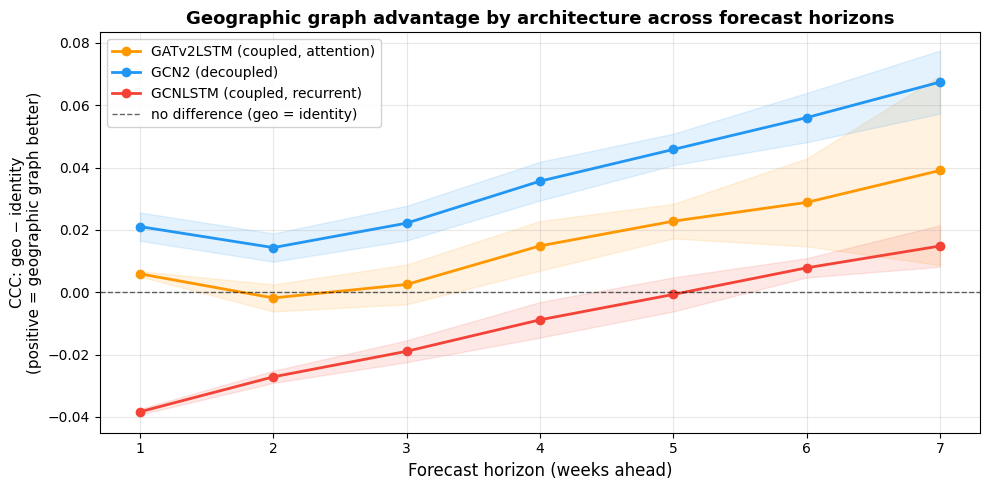

In [38]:
gap_gcn2['architecture']    = 'GCN2 (decoupled)'
gap_gatv2['architecture']   = 'GATv2LSTM (coupled, attention)'
gap_gcnlstm['architecture'] = 'GCNLSTM (coupled, recurrent)'

all_gaps = pd.concat([gap_gcn2, gap_gatv2, gap_gcnlstm], ignore_index=True)
gap_agg  = all_gaps.groupby(['horizon', 'architecture'])['gap'].agg(
    mean='mean', std='std'
).reset_index()

palette = {
    'GCN2 (decoupled)'             : '#2196F3',
    'GATv2LSTM (coupled, attention)': '#FF9800',
    'GCNLSTM (coupled, recurrent)' : '#F44336',
}

fig, ax = plt.subplots(figsize=(10, 5))

for arch in gap_agg['architecture'].unique():
    sub   = gap_agg[gap_agg['architecture'] == arch].sort_values('horizon')
    color = palette[arch]
    ax.plot(sub['horizon'], sub['mean'],
            label=arch, color=color, marker='o', linewidth=2)
    ax.fill_between(sub['horizon'],
                    sub['mean'] - sub['std'],
                    sub['mean'] + sub['std'],
                    color=color, alpha=0.12)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6,
           label='no difference (geo = identity)')
ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
ax.set_ylabel('CCC: geo − identity\n(positive = geographic graph better)', fontsize=11)
ax.set_title('Geographic graph advantage by architecture across forecast horizons',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

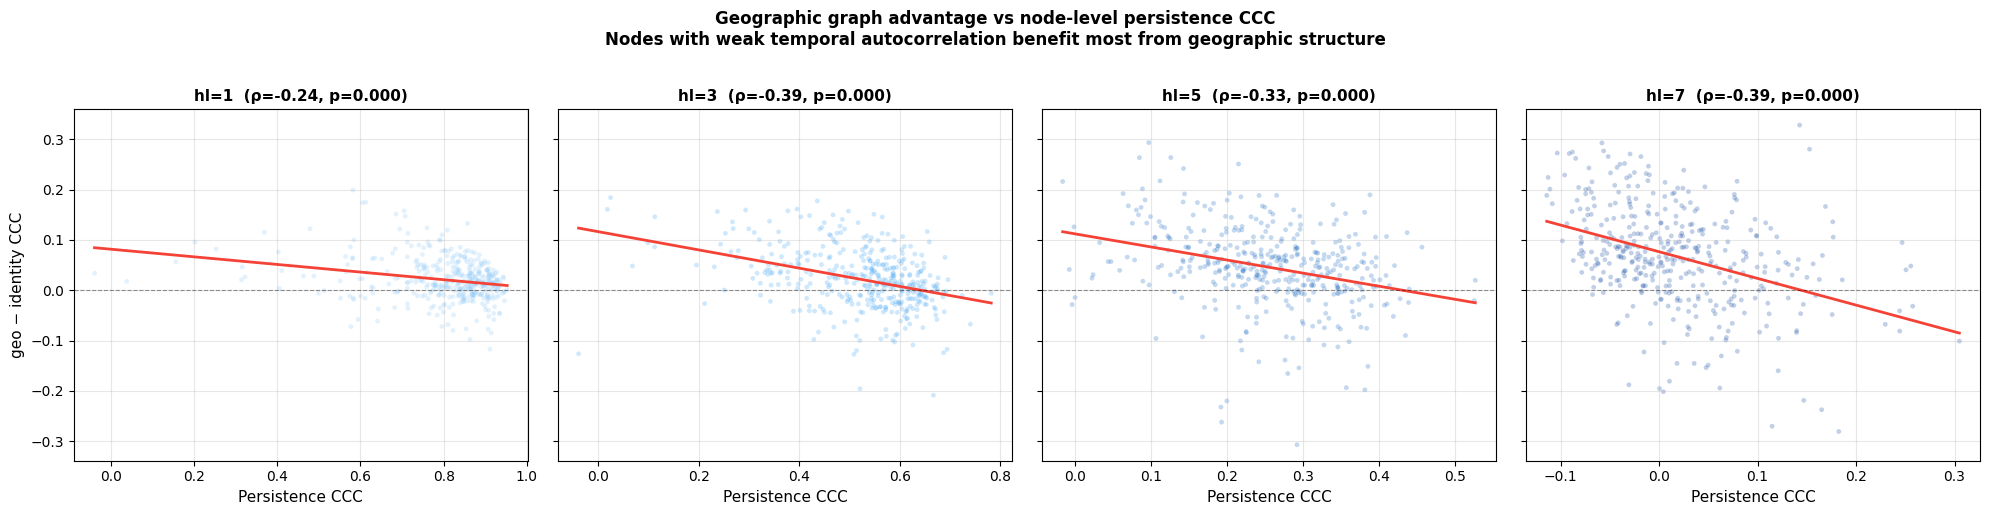


── hl=1: geo−identity gap as % of persistence CCC ────
  Mean gap:          0.0211 CCC
  Mean relative gap: 3.46%
  Median rel. gap:   2.00%
  Std rel. gap:      8.25%

── hl=1: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.250  p=0.0000
  Spearman r=-0.236  p=0.0000
  Interpretation: negative = low persistence nodes benefit more

── hl=2: geo−identity gap as % of persistence CCC ────
  Mean gap:          0.0143 CCC
  Mean relative gap: 3.61%
  Median rel. gap:   1.59%
  Std rel. gap:      15.92%

── hl=2: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.332  p=0.0000
  Spearman r=-0.353  p=0.0000
  Interpretation: negative = low persistence nodes benefit more

── hl=3: geo−identity gap as % of persistence CCC ────
  Mean gap:          0.0222 CCC
  Mean relative gap: 7.85%
  Median rel. gap:   3.18%
  Std rel. gap:      41.79%

── hl=3: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.374  p=0.0000
  Spearman r=-0.385  p=0.0000
  Interpreta

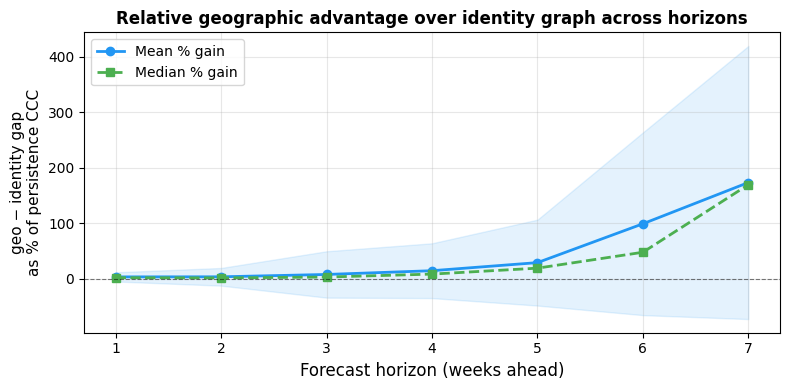

In [44]:
import scipy.stats

def analyse_node_benefit(metrics_df, horizons=[1,3,5,7],
                         geo_model='gcn_geo', identity_model='gcn_identity',
                         pers_model='persistence', clip_pct=500):
    """
    Two analyses:
    1. Geo-identity CCC gap as % of persistence CCC
    2. Correlation between persistence CCC and geo-identity gap per node
    """

    results = {}

    for hl in horizons:
        hl_df = metrics_df[metrics_df['horizon'] == hl].copy()
        hl_df['node'] = hl_df['node'].astype(int)

        # ── collect per-node values averaged across seeds ─────────────────
        def node_mean(model):
            return (hl_df[hl_df['model'] == model]
                    .groupby('node')['ccc']
                    .mean())

        geo  = node_mean(geo_model)
        iden = node_mean(identity_model)
        pers = node_mean(pers_model)

        common = geo.index.intersection(iden.index).intersection(pers.index)
        geo    = geo.loc[common]
        iden   = iden.loc[common]
        pers   = pers.loc[common]

        # drop NaN
        mask   = ~(geo.isna() | iden.isna() | pers.isna() | (pers == 0))
        geo    = geo[mask]
        iden   = iden[mask]
        pers   = pers[mask]

        gap         = geo - iden
        rel_gap     = gap / pers.abs() * 100   # % of persistence CCC
        rel_gap = (gap / pers.abs() * 100).clip(-clip_pct, clip_pct)

        # ── 1. relative gain summary ──────────────────────────────────────
        print(f"\n── hl={hl}: geo−identity gap as % of persistence CCC ────")
        print(f"  Mean gap:          {gap.mean():.4f} CCC")
        print(f"  Mean relative gap: {rel_gap.mean():.2f}%")
        print(f"  Median rel. gap:   {rel_gap.median():.2f}%")
        print(f"  Std rel. gap:      {rel_gap.std():.2f}%")

        # ── 2. correlation: persistence CCC vs geo-identity gap ───────────
        r, p = scipy.stats.pearsonr(pers, gap)
        rs, ps = scipy.stats.spearmanr(pers, gap)
        print(f"\n── hl={hl}: correlation(persistence CCC, geo−identity gap)")
        print(f"  Pearson  r={r:.3f}  p={p:.4f}")
        print(f"  Spearman r={rs:.3f}  p={ps:.4f}")
        print(f"  Interpretation: {'negative = low persistence nodes benefit more' if r < 0 else 'positive = high persistence nodes benefit more'}")

        results[hl] = pd.DataFrame({
            'node'      : common[mask],
            'pers_ccc'  : pers.values,
            'geo_ccc'   : geo.values,
            'iden_ccc'  : iden.values,
            'gap'        : gap.values,
            'rel_gap'   : rel_gap.values,
        })

    return results


def plot_node_benefit(
    results:    dict,
    horizons:   list = [1, 3, 5, 7],
):
    """
    Scatter plot: persistence CCC vs geo-identity gap per node.
    One panel per horizon.
    """
    n     = len(horizons)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, hl in zip(axes, horizons):
        df    = results[hl]
        r, p  = scipy.stats.pearsonr(df['pers_ccc'], df['gap'])

        ax.scatter(df['pers_ccc'], df['gap'],
                   alpha=0.3, s=15, color='#2196F3', edgecolors='none')

        # regression line
        m, b  = np.polyfit(df['pers_ccc'], df['gap'], 1)
        x_line = np.linspace(df['pers_ccc'].min(), df['pers_ccc'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='#F44336', linewidth=2)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xlabel('Persistence CCC', fontsize=11)
        ax.set_ylabel('geo − identity CCC gap', fontsize=11)
        ax.set_title(f'hl={hl}\nr={r:.3f}  p={p:.4f}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Node-level geo advantage vs persistence CCC\n'
        '(negative correlation = low-persistence nodes benefit most from geographic structure)',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()
    return fig


def plot_relative_gain_by_horizon(results: dict):
    """
    Line plot of mean % geo-identity gain relative to persistence CCC across horizons.
    """
    horizons   = sorted(results.keys())
    mean_rel   = [results[hl]['rel_gap'].mean()   for hl in horizons]
    median_rel = [results[hl]['rel_gap'].median() for hl in horizons]
    std_rel    = [results[hl]['rel_gap'].std()    for hl in horizons]

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(horizons, mean_rel,   marker='o', linewidth=2,
            color='#2196F3', label='Mean % gain')
    ax.plot(horizons, median_rel, marker='s', linewidth=2,
            color='#4CAF50', label='Median % gain', linestyle='--')
    ax.fill_between(horizons,
                    np.array(mean_rel) - np.array(std_rel),
                    np.array(mean_rel) + np.array(std_rel),
                    alpha=0.12, color='#2196F3')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
    ax.set_ylabel('geo − identity gap\nas % of persistence CCC', fontsize=11)
    ax.set_title('Relative geographic advantage over identity graph across horizons',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

def plot_node_benefit_combined(results, horizons=[1, 3, 5, 7]):
    """Single scatter with all horizons, coloured by horizon."""
    
    all_df = pd.concat([
        results[hl].assign(horizon=hl) for hl in horizons
    ], ignore_index=True)

    # clip relative gap for colour scaling
    all_df['rel_gap_clipped'] = all_df['gap'].clip(-0.5, 0.5)

    palette = {1: '#90CAF9', 3: '#42A5F5', 5: '#1565C0', 7: '#0D47A1'}

    fig, axes = plt.subplots(1, len(horizons), figsize=(5*len(horizons), 5), sharey=True)

    for ax, hl in zip(axes, horizons):
        df   = results[hl].copy()
        df['rel_gap'] = (df['gap'] / df['pers_ccc'].abs() * 100).clip(-500, 500)
        r, p = scipy.stats.spearmanr(df['pers_ccc'], df['gap'])

        ax.scatter(df['pers_ccc'], df['gap'],
                   alpha=0.25, s=12,
                   color=palette[hl], edgecolors='none')

        m, b   = np.polyfit(df['pers_ccc'], df['gap'], 1)
        x_line = np.linspace(df['pers_ccc'].min(), df['pers_ccc'].max(), 100)
        ax.plot(x_line, m*x_line + b, color='#F44336', linewidth=2)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
        ax.set_xlabel('Persistence CCC', fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel('geo − identity CCC', fontsize=11)
        ax.set_title(f'hl={hl}  (ρ={r:.2f}, p={p:.3f})', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Geographic graph advantage vs node-level persistence CCC\n'
        'Nodes with weak temporal autocorrelation benefit most from geographic structure',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()
    return fig

fig_combined = plot_node_benefit_combined(node_results, horizons=[1, 3, 5, 7])

# ── run ───────────────────────────────────────────────────────────────────
horizons = list(range(1, 8))
node_results = analyse_node_benefit(
    metrics_df = metrics_df.copy(),
    horizons   = horizons,
    geo_model      = 'gcn_geo',
    identity_model = 'gcn_identity',
    pers_model     = 'persistence',
)

# fig_scatter = plot_node_benefit(node_results, horizons)
fig_rel     = plot_relative_gain_by_horizon(node_results)
# fig_3       = plot_node_benefit_combined(node_results, [1,3,5,7])

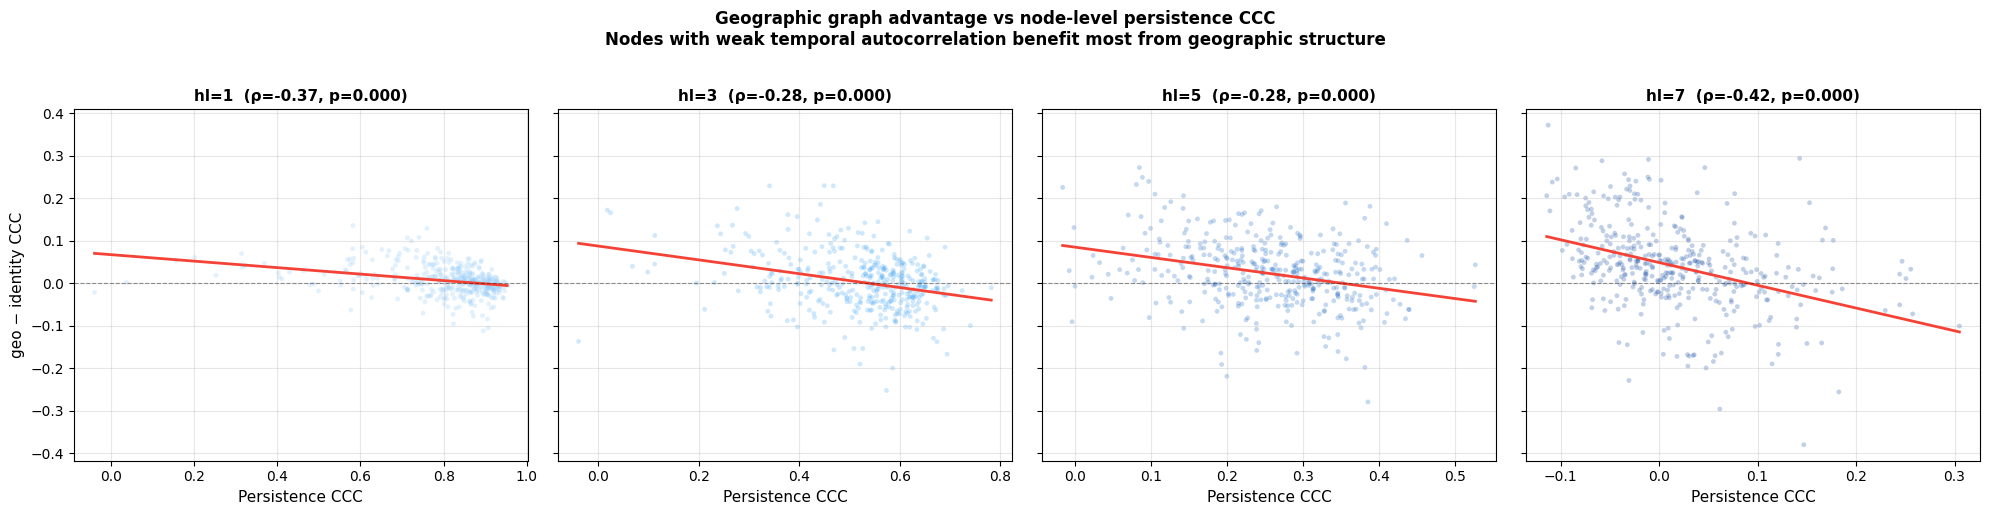


── hl=1: geo−identity gap as % of persistence CCC ────
  Mean gap:          0.0059 CCC
  Mean relative gap: 1.05%
  Median rel. gap:   0.44%
  Std rel. gap:      5.93%

── hl=1: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.310  p=0.0000
  Spearman r=-0.374  p=0.0000
  Interpretation: negative = low persistence nodes benefit more

── hl=2: geo−identity gap as % of persistence CCC ────
  Mean gap:          -0.0018 CCC
  Mean relative gap: 1.02%
  Median rel. gap:   -0.77%
  Std rel. gap:      15.79%

── hl=2: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.324  p=0.0000
  Spearman r=-0.326  p=0.0000
  Interpretation: negative = low persistence nodes benefit more

── hl=3: geo−identity gap as % of persistence CCC ────
  Mean gap:          0.0025 CCC
  Mean relative gap: 3.46%
  Median rel. gap:   -0.03%
  Std rel. gap:      42.40%

── hl=3: correlation(persistence CCC, geo−identity gap)
  Pearson  r=-0.303  p=0.0000
  Spearman r=-0.277  p=0.0000
  Interpr

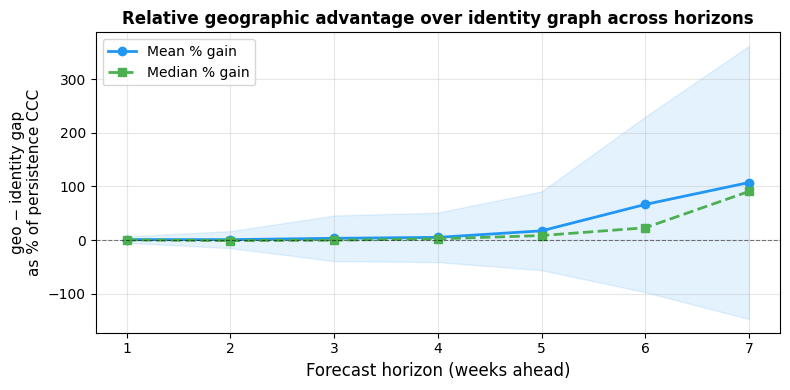

In [46]:
import scipy.stats

def analyse_node_benefit(metrics_df, horizons=[1,3,5,7],
                         geo_model='gcn_geo', identity_model='gcn_identity',
                         pers_model='persistence', clip_pct=500):
    """
    Two analyses:
    1. Geo-identity CCC gap as % of persistence CCC
    2. Correlation between persistence CCC and geo-identity gap per node
    """

    results = {}

    for hl in horizons:
        hl_df = metrics_df[metrics_df['horizon'] == hl].copy()
        hl_df['node'] = hl_df['node'].astype(int)

        # ── collect per-node values averaged across seeds ─────────────────
        def node_mean(model):
            return (hl_df[hl_df['model'] == model]
                    .groupby('node')['ccc']
                    .mean())

        geo  = node_mean(geo_model)
        iden = node_mean(identity_model)
        pers = node_mean(pers_model)

        common = geo.index.intersection(iden.index).intersection(pers.index)
        geo    = geo.loc[common]
        iden   = iden.loc[common]
        pers   = pers.loc[common]

        # drop NaN
        mask   = ~(geo.isna() | iden.isna() | pers.isna() | (pers == 0))
        geo    = geo[mask]
        iden   = iden[mask]
        pers   = pers[mask]

        gap         = geo - iden
        rel_gap     = gap / pers.abs() * 100   # % of persistence CCC
        rel_gap = (gap / pers.abs() * 100).clip(-clip_pct, clip_pct)

        # ── 1. relative gain summary ──────────────────────────────────────
        print(f"\n── hl={hl}: geo−identity gap as % of persistence CCC ────")
        print(f"  Mean gap:          {gap.mean():.4f} CCC")
        print(f"  Mean relative gap: {rel_gap.mean():.2f}%")
        print(f"  Median rel. gap:   {rel_gap.median():.2f}%")
        print(f"  Std rel. gap:      {rel_gap.std():.2f}%")

        # ── 2. correlation: persistence CCC vs geo-identity gap ───────────
        r, p = scipy.stats.pearsonr(pers, gap)
        rs, ps = scipy.stats.spearmanr(pers, gap)
        print(f"\n── hl={hl}: correlation(persistence CCC, geo−identity gap)")
        print(f"  Pearson  r={r:.3f}  p={p:.4f}")
        print(f"  Spearman r={rs:.3f}  p={ps:.4f}")
        print(f"  Interpretation: {'negative = low persistence nodes benefit more' if r < 0 else 'positive = high persistence nodes benefit more'}")

        results[hl] = pd.DataFrame({
            'node'      : common[mask],
            'pers_ccc'  : pers.values,
            'geo_ccc'   : geo.values,
            'iden_ccc'  : iden.values,
            'gap'        : gap.values,
            'rel_gap'   : rel_gap.values,
        })

    return results


def plot_node_benefit(
    results:    dict,
    horizons:   list = [1, 3, 5, 7],
):
    """
    Scatter plot: persistence CCC vs geo-identity gap per node.
    One panel per horizon.
    """
    n     = len(horizons)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, hl in zip(axes, horizons):
        df    = results[hl]
        r, p  = scipy.stats.pearsonr(df['pers_ccc'], df['gap'])

        ax.scatter(df['pers_ccc'], df['gap'],
                   alpha=0.3, s=15, color='#2196F3', edgecolors='none')

        # regression line
        m, b  = np.polyfit(df['pers_ccc'], df['gap'], 1)
        x_line = np.linspace(df['pers_ccc'].min(), df['pers_ccc'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='#F44336', linewidth=2)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xlabel('Persistence CCC', fontsize=11)
        ax.set_ylabel('geo − identity CCC gap', fontsize=11)
        ax.set_title(f'hl={hl}\nr={r:.3f}  p={p:.4f}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Node-level geo advantage vs persistence CCC\n'
        '(negative correlation = low-persistence nodes benefit most from geographic structure)',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()
    return fig


def plot_relative_gain_by_horizon(results: dict):
    """
    Line plot of mean % geo-identity gain relative to persistence CCC across horizons.
    """
    horizons   = sorted(results.keys())
    mean_rel   = [results[hl]['rel_gap'].mean()   for hl in horizons]
    median_rel = [results[hl]['rel_gap'].median() for hl in horizons]
    std_rel    = [results[hl]['rel_gap'].std()    for hl in horizons]

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(horizons, mean_rel,   marker='o', linewidth=2,
            color='#2196F3', label='Mean % gain')
    ax.plot(horizons, median_rel, marker='s', linewidth=2,
            color='#4CAF50', label='Median % gain', linestyle='--')
    ax.fill_between(horizons,
                    np.array(mean_rel) - np.array(std_rel),
                    np.array(mean_rel) + np.array(std_rel),
                    alpha=0.12, color='#2196F3')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
    ax.set_ylabel('geo − identity gap\nas % of persistence CCC', fontsize=11)
    ax.set_title('Relative geographic advantage over identity graph across horizons',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

def plot_node_benefit_combined(results, horizons=[1, 3, 5, 7]):
    """Single scatter with all horizons, coloured by horizon."""
    
    all_df = pd.concat([
        results[hl].assign(horizon=hl) for hl in horizons
    ], ignore_index=True)

    # clip relative gap for colour scaling
    all_df['rel_gap_clipped'] = all_df['gap'].clip(-0.5, 0.5)

    palette = {1: '#90CAF9', 3: '#42A5F5', 5: '#1565C0', 7: '#0D47A1'}

    fig, axes = plt.subplots(1, len(horizons), figsize=(5*len(horizons), 5), sharey=True)

    for ax, hl in zip(axes, horizons):
        df   = results[hl].copy()
        df['rel_gap'] = (df['gap'] / df['pers_ccc'].abs() * 100).clip(-500, 500)
        r, p = scipy.stats.spearmanr(df['pers_ccc'], df['gap'])

        ax.scatter(df['pers_ccc'], df['gap'],
                   alpha=0.25, s=12,
                   color=palette[hl], edgecolors='none')

        m, b   = np.polyfit(df['pers_ccc'], df['gap'], 1)
        x_line = np.linspace(df['pers_ccc'].min(), df['pers_ccc'].max(), 100)
        ax.plot(x_line, m*x_line + b, color='#F44336', linewidth=2)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
        ax.set_xlabel('Persistence CCC', fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel('geo − identity CCC', fontsize=11)
        ax.set_title(f'hl={hl}  (ρ={r:.2f}, p={p:.3f})', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Geographic graph advantage vs node-level persistence CCC\n'
        'Nodes with weak temporal autocorrelation benefit most from geographic structure',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()
    return fig

fig_combined = plot_node_benefit_combined(node_results, horizons=[1, 3, 5, 7])

# ── run ───────────────────────────────────────────────────────────────────
horizons = list(range(1, 8))
node_results = analyse_node_benefit(
    metrics_df = metrics_df.copy(),
    horizons   = horizons,
    geo_model      = 'gatv2lstm_geo',
    identity_model = 'gatv2lstm_identity',
    pers_model     = 'persistence',
)

# fig_scatter = plot_node_benefit(node_results, horizons)
fig_rel     = plot_relative_gain_by_horizon(node_results)
# fig_3       = plot_node_benefit_combined(node_results, [1,3,5,7])